In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/rice_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [4]:
import os

os.listdir("/content/rice_data/Rice_Image_Dataset")

['Basmati',
 'Arborio',
 'Ipsala',
 'Jasmine',
 'Rice_Citation_Request.txt',
 'Karacadag']

Dataset Selection

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from PIL import Image

Dataset Selection

In [16]:
dataset_path = "/content/rice_data/Rice_Image_Dataset"

classes = [
    c for c in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path,c))
]

print(classes)

['.ipynb_checkpoints', 'Basmati', 'Arborio', 'Ipsala', 'Jasmine', 'Karacadag']


In [18]:
classes = [
    c for c in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path,c))
    and len(os.listdir(os.path.join(dataset_path,c))) > 0
]

print(classes)

['Basmati', 'Arborio', 'Ipsala', 'Jasmine', 'Karacadag']


Number of classes

In [19]:
print("Number of classes:", len(classes))

Number of classes: 5


Number of images per class

In [20]:
for cls in classes:
    total = len(
        os.listdir(os.path.join(dataset_path, cls))
    )
    print(cls,":",total)

Basmati : 15000
Arborio : 15000
Ipsala : 15000
Jasmine : 15000
Karacadag : 15000


Check class imbalance

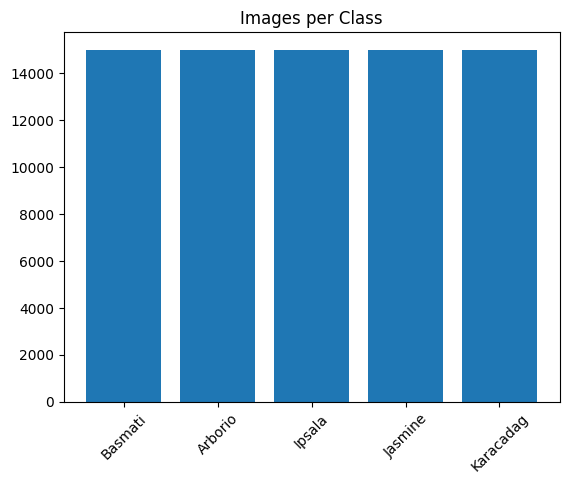

In [21]:
class_count = {}

for cls in classes:
    class_count[cls] = len(
        os.listdir(os.path.join(dataset_path,cls))
    )


plt.bar(
    class_count.keys(),
    class_count.values()
)

plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

Image Dimensions

In [22]:
sample_image = os.path.join(
    dataset_path,
    classes[0],
    os.listdir(
        os.path.join(dataset_path,classes[0])
    )[0]
)


img = Image.open(sample_image)

print("Width,Height:", img.size)

print(
    "Channels:",
    len(img.getbands())
)

Width,Height: (250, 250)
Channels: 3


Display Sample Images

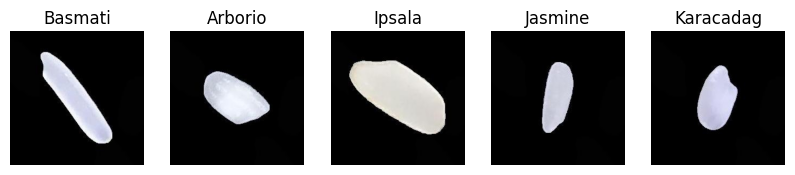

In [23]:
plt.figure(figsize=(10,5))


for i,cls in enumerate(classes):

    img_name = os.listdir(
        os.path.join(dataset_path,cls)
    )[0]


    img = Image.open(
        os.path.join(
            dataset_path,
            cls,
            img_name
        )
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")


plt.show()

Problem Statement

The objective of this project is to build a CNN model
that can classify rice grain images into 5 categories:
Arborio, Basmati, Ipsala, Jasmine, and Karacadag.

Rice classification is important for quality checking,
automation in agriculture, and reducing manual inspection.

The expected output of the model is the predicted rice class.

In [12]:
import tensorflow as tf

from tensorflow.keras import layers, models

Data Preprocessing
Train Validation Split + Resize

In [24]:
train_ds = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=(224,224),

    batch_size=32
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=(224,224),

    batch_size=32
)

Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


Data Augmentation

In [25]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomTranslation(0.1,0.1),

    layers.RandomContrast(0.2)

])

CNN Model Implementation

In [26]:
model1 = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),


    layers.Conv2D(32,3,activation='relu'),

    layers.MaxPooling2D(),


    layers.Conv2D(64,3,activation='relu'),

    layers.MaxPooling2D(),


    layers.Conv2D(128,3,activation='relu'),

    layers.MaxPooling2D(),


    layers.Flatten(),


    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),


    layers.Dense(5,activation='softmax')

])

Compile

In [27]:
model1.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

Train

In [28]:
history1 = model1.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10

)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 137s 67ms/step - accuracy: 0.8259 - loss: 0.4233 - val_accuracy: 0.9007 - val_loss: 0.2388
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 129s 69ms/step - accuracy: 0.9478 - loss: 0.1535 - val_accuracy: 0.9001 - val_loss: 0.2743
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 135s 65ms/step - accuracy: 0.9618 - loss: 0.1152 - val_accuracy: 0.9751 - val_loss: 0.0706
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 122s 65ms/step - accuracy: 0.9658 - loss: 0.1046 - val_accuracy: 0.9607 - val_loss: 0.1160
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 122s 65ms/step - accuracy: 0.9710 - loss: 0.0910 - val_accuracy: 0.9243 - val_loss: 0.2646
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 120s 64ms/step - accuracy: 0.9755 - loss: 0.0782 - val_accuracy: 0.9468 - val_loss: 0.1835
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 120s 64ms/step - accuracy: 0.9754 - loss: 0.0771 - val_accuracy: 0.9601 - val_loss: 0.1376
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 65ms/step - accuracy: 

Accuracy & Loss Curves

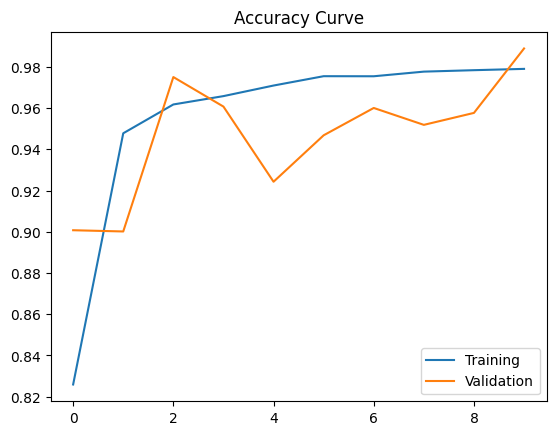

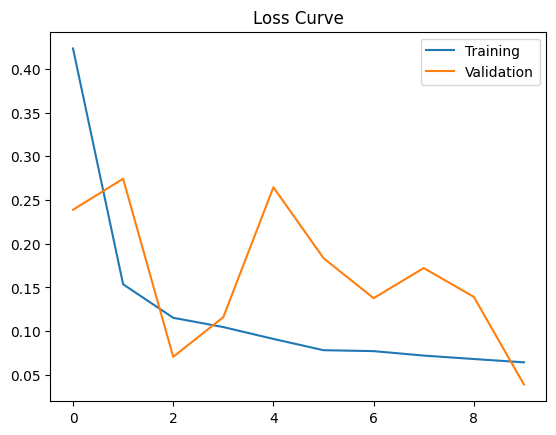

In [29]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

plt.legend(
    ["Training","Validation"]
)

plt.title("Accuracy Curve")

plt.show()
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

plt.legend(
    ["Training","Validation"]
)

plt.title("Loss Curve")

plt.show()